1. В файле «baseball.csv» находится выборка с информацией по игрокам в бейсбол, включая
статистику их результативности, время участия в играх, лига, зарплата и т.д. Name (имя) нужно
считать идентификатором записи. Загрузите этот файл и произведите следующие действия для
кластерного анализа.

In [5]:
import pandas as pd


df = pd.read_csv("~/Рабочий стол/baseball.csv")

#df.nunique()
print(df)

                  Name         Team  nAtBat  nHits  nHome  nRuns  nRBI  nBB  \
0       Allanson, Andy    Cleveland     293     66      1     30    29   14   
1          Ashby, Alan      Houston     315     81      7     24    38   39   
2          Davis, Alan      Seattle     479    130     18     66    72   76   
3        Dawson, Andre     Montreal     496    141     20     65    78   37   
4    Galarraga, Andres     Montreal     321     87     10     39    42   30   
..                 ...          ...     ...    ...    ...    ...   ...  ...   
317      McGee, Willie     St Louis     497    127      7     65    48   37   
318   Randolph, Willie     New York     492    136      5     76    50   94   
319    Tolleson, Wayne      Chicago     475    126      3     61    43   52   
320     Upshaw, Willie      Toronto     573    144      9     85    60   78   
321     Wilson, Willie  Kansas City     631    170      9     77    44   31   

     YrMajor  CrAtBat  ...  CrBB    League  Divisio

2. Обработка пропусков. Переменная Salary (и log Salary) может содержать пропуски, произведите подстановку пропусков методом согласно вашему варианту. Пересчитайте
logSalary как log(1+Salary), чтобы получить более симметричное распределение.

KnnImputer
(neighbors=3)

In [6]:
from sklearn.impute import KNNImputer
import numpy as np

knn_imp = KNNImputer(n_neighbors=3)
df[['Salary']] = knn_imp.fit_transform(df[['Salary']])
df['logSalary'] = np.log1p(df['Salary'])

df1=df

print(df.head())

                Name       Team  nAtBat  nHits  nHome  nRuns  nRBI  nBB  \
0     Allanson, Andy  Cleveland     293     66      1     30    29   14   
1        Ashby, Alan    Houston     315     81      7     24    38   39   
2        Davis, Alan    Seattle     479    130     18     66    72   76   
3      Dawson, Andre   Montreal     496    141     20     65    78   37   
4  Galarraga, Andres   Montreal     321     87     10     39    42   30   

   YrMajor  CrAtBat  ...  CrBB    League  Division  Position  nOuts nAssts  \
0        1      293  ...    14  American      East         C    446     33   
1       14     3449  ...   375  National      West         C    632     43   
2        3     1624  ...   263  American      West        1B    880     82   
3       11     5628  ...   354  National      East        RF    200     11   
4        2      396  ...    33  National      East        1B    805     40   

  nError      Salary  Div  logSalary  
0     20  535.925882   AE   6.285860  
1 

3. Нормализация переменных – приведите числовые переменные к близким шкалам с помощью
методов для вашего варианта и закодируйте категориальные с помощью OneHotEncoder.

MinMaxScaler

In [7]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

mm = MinMaxScaler()
num_col = df.select_dtypes(include=["number"]).columns #только где числа
df[num_col] = mm.fit_transform(df[num_col])

encoder = OneHotEncoder(sparse_output=False, drop="first") #возвращаем массив и удаляем 1 столбец
cat_col = df.select_dtypes(include=["object"]).columns #только текстовые столбцы
en_cats = encoder.fit_transform(df[cat_col])

df_cat = pd.DataFrame(en_cats, columns=encoder.get_feature_names_out())#создаем дф
df = df.drop(columns=cat_col).reset_index(drop=True) #удаляем текст колонки
df = pd.concat([df, df_cat], axis=1) #объединяем

print(df)

       nAtBat     nHits  nHome     nRuns      nRBI       nBB   YrMajor  \
0    0.296429  0.169082  0.025  0.152542  0.185841  0.107843  0.000000   
1    0.335714  0.241546  0.175  0.101695  0.265487  0.352941  0.565217   
2    0.628571  0.478261  0.450  0.457627  0.566372  0.715686  0.086957   
3    0.658929  0.531401  0.500  0.449153  0.619469  0.333333  0.434783   
4    0.346429  0.270531  0.250  0.228814  0.300885  0.264706  0.043478   
..        ...       ...    ...       ...       ...       ...       ...   
317  0.660714  0.463768  0.175  0.449153  0.353982  0.333333  0.173913   
318  0.651786  0.507246  0.125  0.542373  0.371681  0.892157  0.478261   
319  0.621429  0.458937  0.075  0.415254  0.309735  0.480392  0.217391   
320  0.796429  0.545894  0.225  0.618644  0.460177  0.735294  0.304348   
321  0.900000  0.671498  0.225  0.550847  0.318584  0.274510  0.434783   

      CrAtBat    CrHits    CrHome  ...  Position_OD  Position_OF  Position_OS  \
0    0.009145  0.007579  0.001

4. С помощью восходящей иерархической кластеризации с выбранными параметрами
расстояния согласно вашему варианту постройте кластерную модель данных и дендрограмму
для топ 20 кластеров.

link=complete,
dist=manhattan

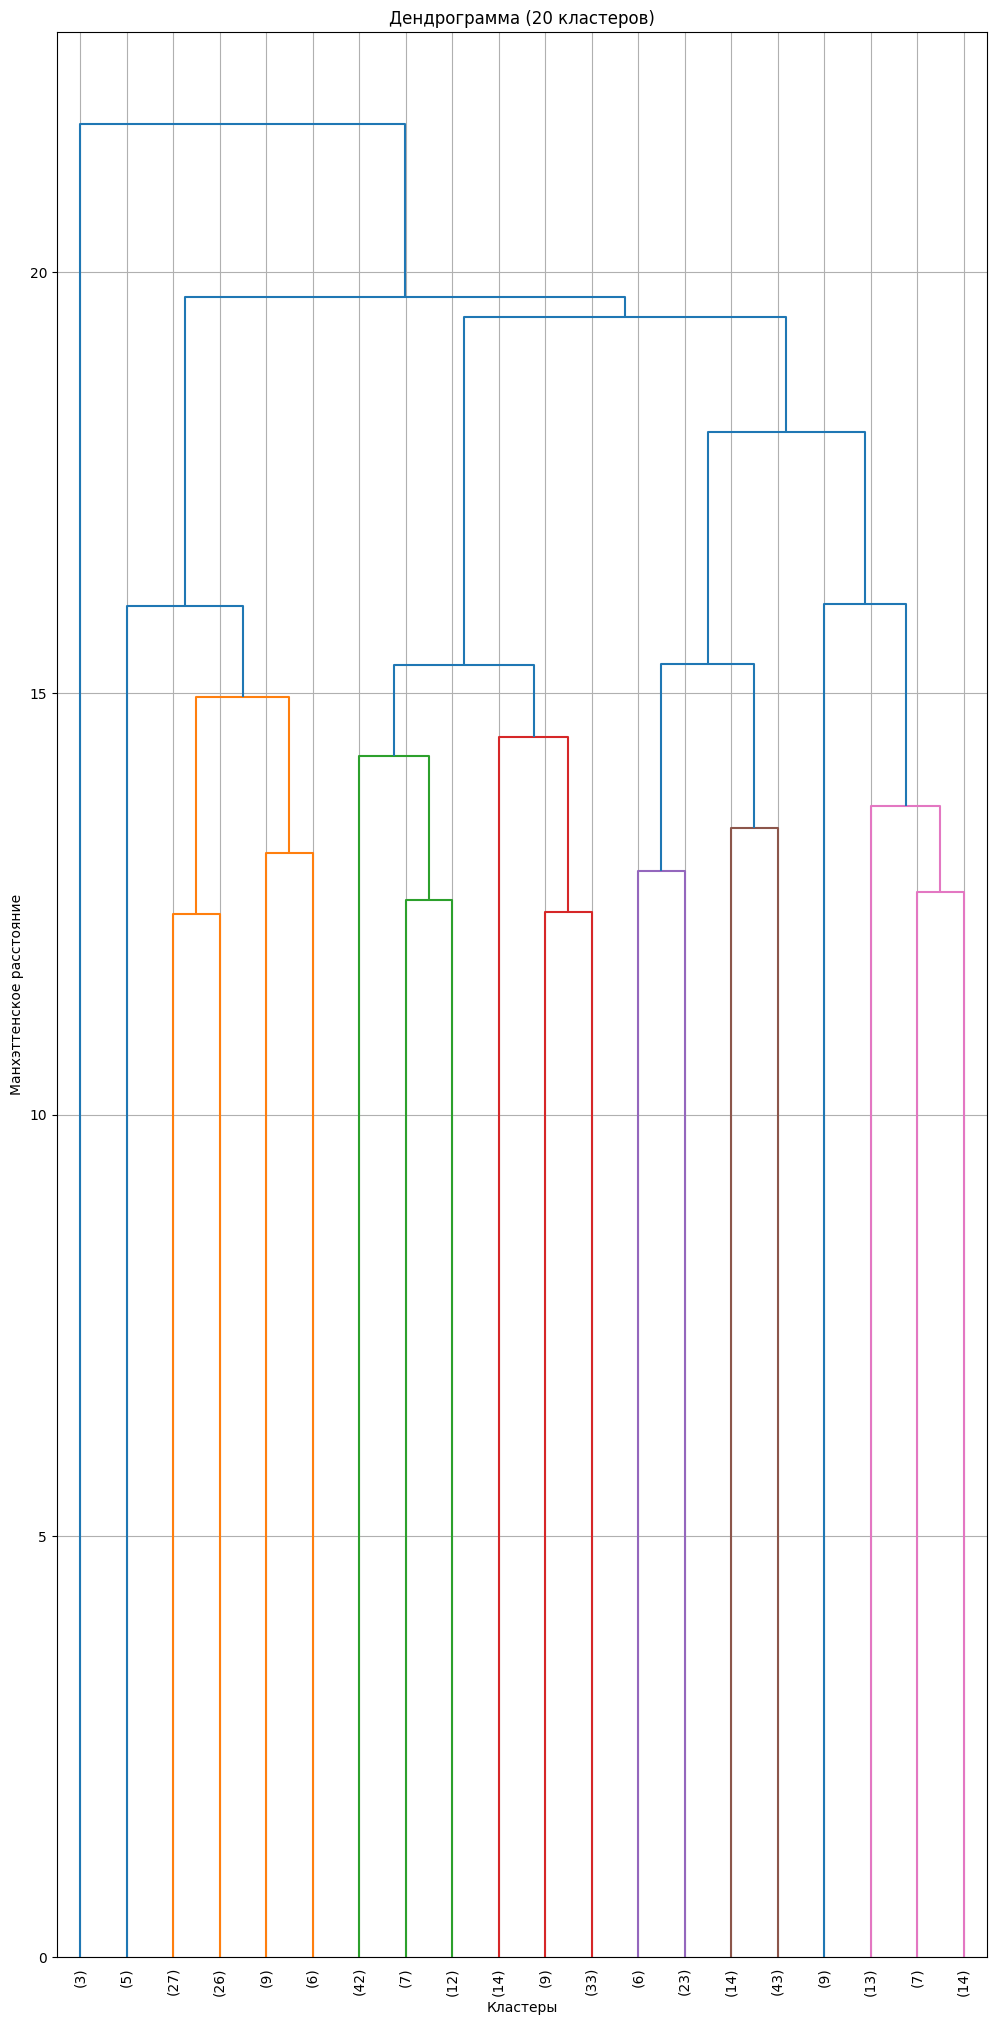

In [8]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram

# Вычисляем матрицу расстояний и linkage
Z = linkage(df.values, method='complete', metric='cityblock')

# Построим дендрограмму для топ-20 кластеров
plt.figure(figsize=(12, 25))
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=90., leaf_font_size=10.)
plt.title("Дендрограмма (20 кластеров)")
plt.xlabel("Кластеры")
plt.ylabel("Манхэттенское расстояние")
plt.grid(True)
plt.show()

5. Рассчитайте значение критерия pseudoF для вариантов кластеризации 2-20 кластеров,
постройте график зависимости критерия от числа кластеров и выберите оптимальное (первый
локальный пик критерия при обходе от малого числа кластеров к большому). Отметьте точку
на графике. Сколько кластеров получилось?

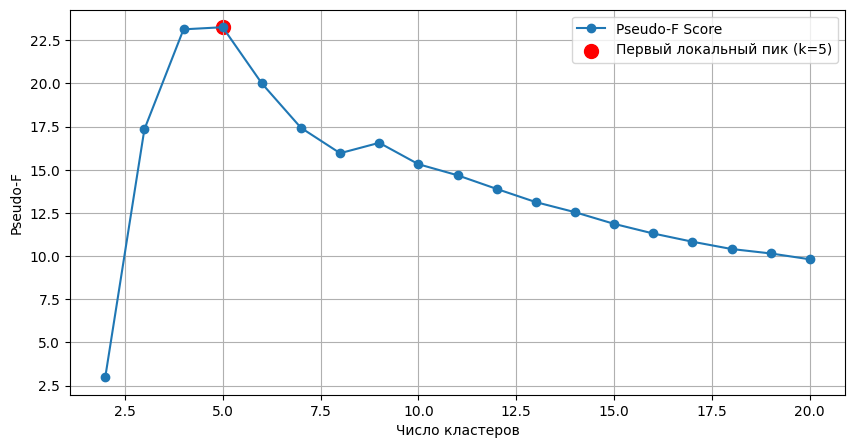

Оптимальное число кластеров 5


In [9]:
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

scores = []
cluster_range = range(2, 21)

for k in cluster_range:
    clustering = AgglomerativeClustering(n_clusters=k, metric='manhattan', linkage='complete')
    met_clus = clustering.fit_predict(df)
    score = calinski_harabasz_score(df, met_clus)
    scores.append(score)

local_peaks = []
for i in range(1, len(scores)-1):
    if scores[i] > scores[i-1] and scores[i] > scores[i+1]:
        local_peaks.append((cluster_range[i], scores[i]))

if local_peaks:
    optimal_k, optimal_score = local_peaks[0]
plt.figure(figsize=(10, 5))
plt.plot(cluster_range, scores, marker='o', label='Pseudo-F Score')
plt.scatter(optimal_k, optimal_score, color='red', s=100, label=f'Первый локальный пик (k={optimal_k})')
plt.xlabel('Число кластеров')
plt.ylabel('Pseudo-F')
plt.legend()
plt.grid(True)
plt.show()

print(f"Оптимальное число кластеров {optimal_k}")

6. С помощью метода проекции для вашего варианта постройте отображение на плоскость,
цветом точки укажите номер кластера.

SOM

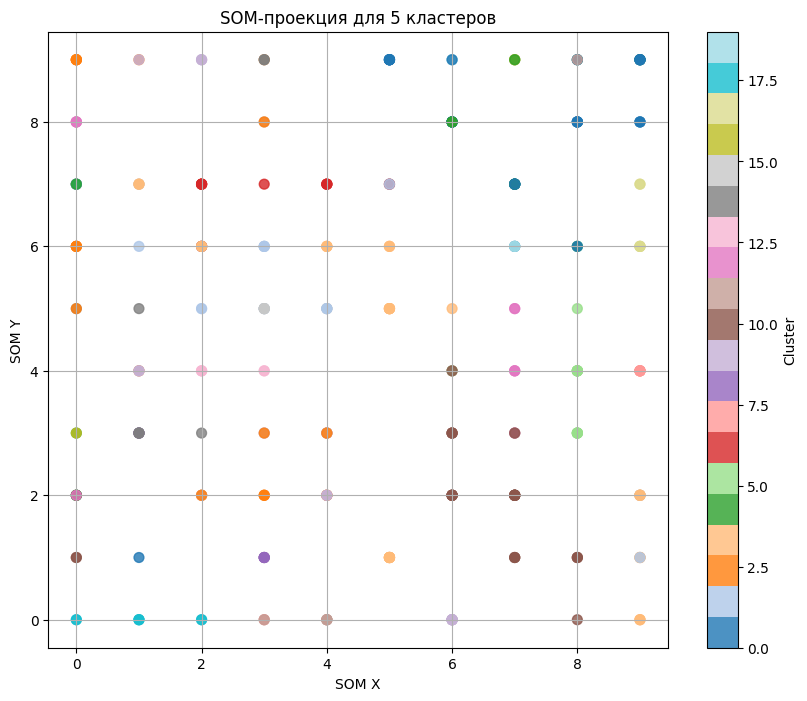

In [10]:
from minisom import MiniSom
import numpy as np
import matplotlib.pyplot as plt

som_x, som_y = 10, 10
som = MiniSom(x=som_x, y=som_y, input_len=df.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
som.random_weights_init(df.values)
som.train(df.values, 1000)

# координаты BMU для каждой точки
coordinates = np.array([som.winner(x) for x in df.values])
x_coords = [c[0] for c in coordinates]
y_coords = [c[1] for c in coordinates]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x_coords, y_coords, c=met_clus, cmap='tab20', s=50, alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title(f'SOM-проекция для {optimal_k} кластеров')
plt.xlabel('SOM X')
plt.ylabel('SOM Y')
plt.grid(True)
plt.show()


7. Выполните кластеризацию сферическими кластерами с прототипом методом из вашего
варианта, также постройте проекцию как на шаге 6, определите наиболее типичного
представителя (по имени) в каждом из кластеров.

KMedoids

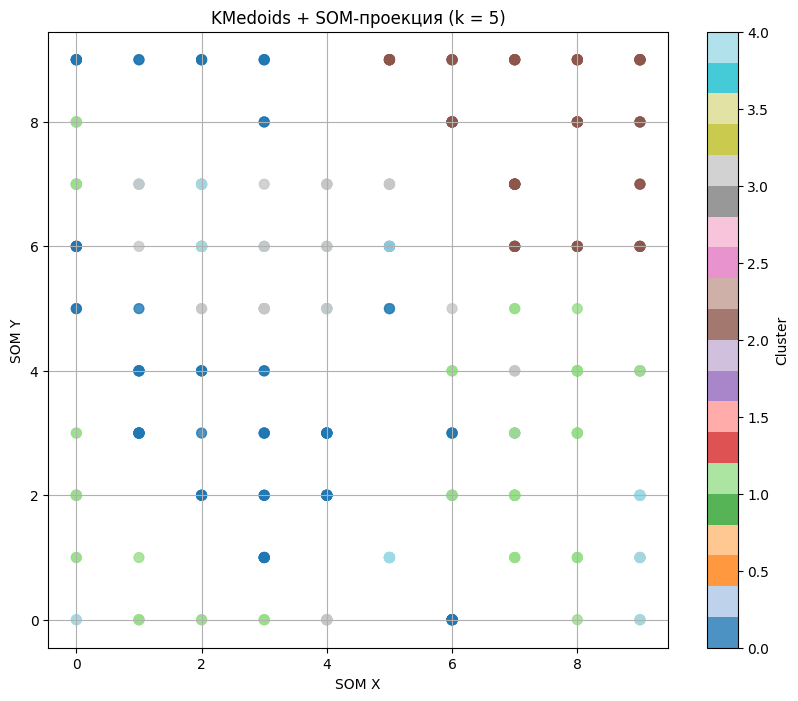


Типичные представители (медоиды):
Кластер 0: Harper, Terry
Кластер 1: Mulliniks, Rance
Кластер 2: Krenchicki, Wayne
Кластер 3: Jones, Ruppert
Кластер 4: Skinner, Joel


In [11]:
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils import calculate_distance_matrix
import numpy as np


df_raw = df.reset_index(drop=True)
df = df.reset_index(drop=True)
np.random.seed(42)
initial_medoids = list(np.random.choice(len(df), optimal_k, replace=False))
# выбор начальных медоидов
initial_medoids = list(np.random.choice(len(df), optimal_k, replace=False))
# расстояние между точками
distance_matrix = calculate_distance_matrix(df.values)
# запуск K-Medoids
kmed = kmedoids(distance_matrix, initial_medoids, data_type='distance_matrix')
kmed.process()
# результаты
clusters = kmed.get_clusters()
final_medoids = kmed.get_medoids()
# метки кластеров
labels_kmedoids = np.zeros(len(df), dtype=int)
for i, cluster in enumerate(clusters):
    for idx in cluster:
        labels_kmedoids[idx] = i

som = MiniSom(x=10, y=10, input_len=df.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
som.random_weights_init(df.values)
som.train(df.values, 1000)
coordinates = np.array([som.winner(x) for x in df.values])
x_coords = [c[0] for c in coordinates]
y_coords = [c[1] for c in coordinates]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x_coords, y_coords, c=labels_kmedoids, cmap='tab20', s=50, alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title(f'KMedoids + SOM-проекция (k = {optimal_k})')
plt.xlabel('SOM X')
plt.ylabel('SOM Y')
plt.grid(True)
plt.show()

df_raw = pd.read_csv("~/Рабочий стол/baseball.csv")
print("\nТипичные представители (медоиды):")
for i, idx in enumerate(final_medoids):
    print(f"Кластер {i}: {df_raw.loc[idx, 'Name']}")



8. Реализуйте шаги 3-7 в виде функции или класса.

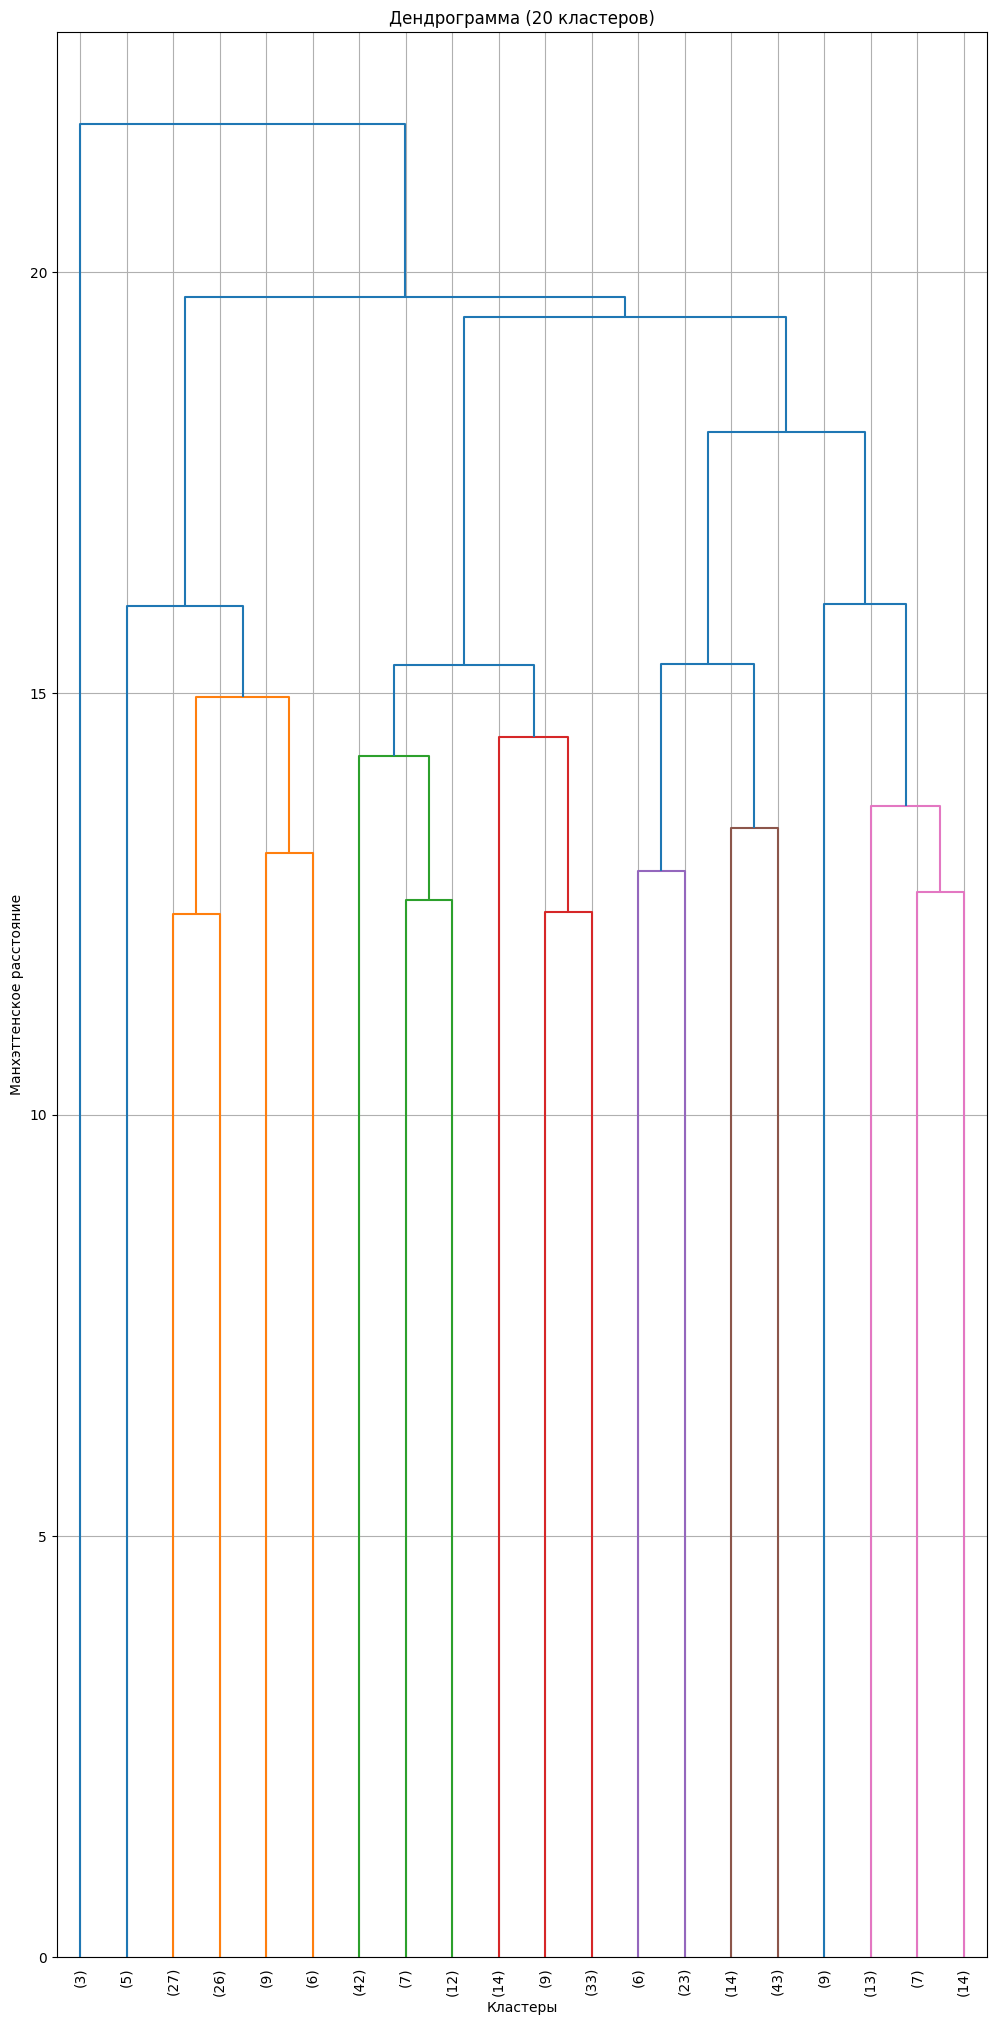

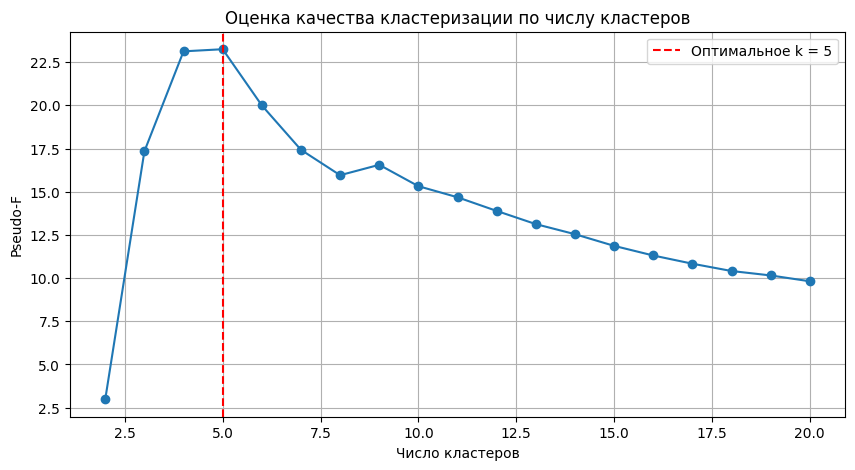

Оптимальное число кластеров: 5


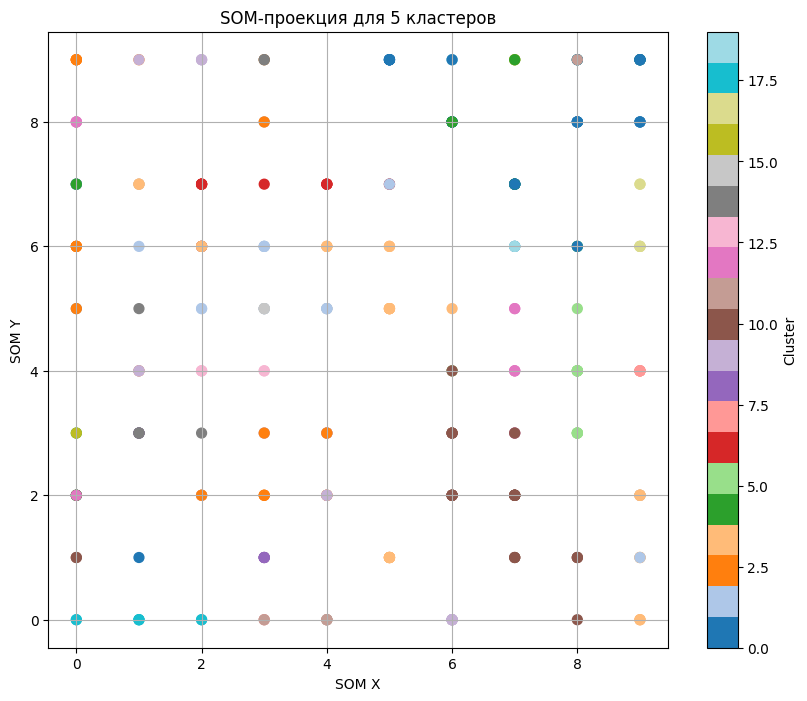

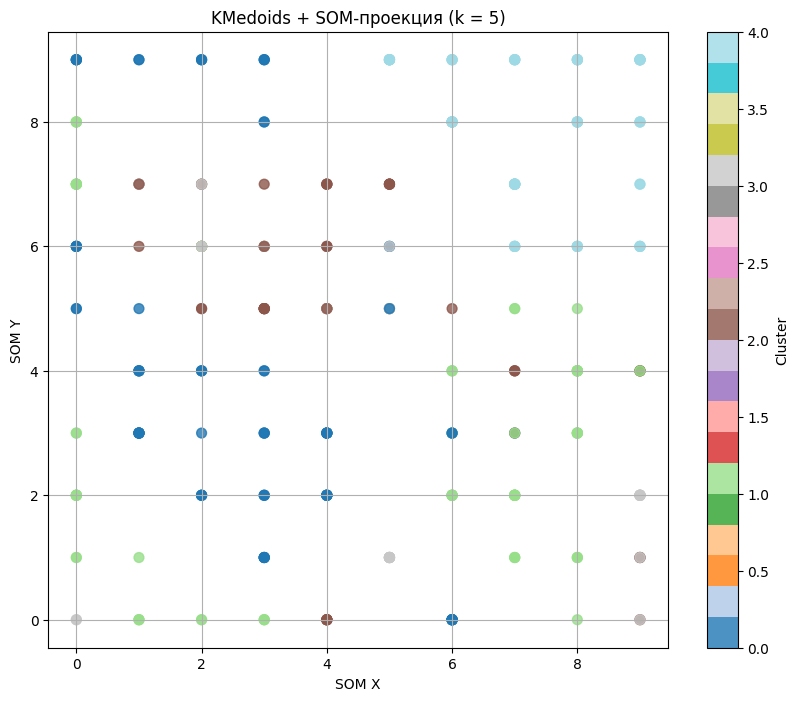


Типичные представители (медоиды):
Кластер 0: Harper, Terry
Кластер 1: Mulliniks, Rance
Кластер 2: Jones, Ruppert
Кластер 3: Skinner, Joel
Кластер 4: Krenchicki, Wayne


In [12]:
from minisom import MiniSom

df_raw = pd.read_csv("~/Рабочий стол/baseball.csv")

def cluster_analysis(df, df_raw):
    df_raw = df_raw.reset_index(drop=True)
    df = df.reset_index(drop=True)
    
    mm = MinMaxScaler() #нормализуем от 0 до 1
    num_col = df.select_dtypes(include=["number"]).columns #берем только числовые
    df[num_col] = mm.fit_transform(df[num_col])

    encoder = OneHotEncoder(sparse_output=False, drop="first")
    cat_col = df.select_dtypes(include=["object"]).columns #берем те колонки, которые с буквами
    en_cats = encoder.fit_transform(df[cat_col]) # обучаем и преобразовываем
    # get_feature_names_out() — метод, который возвращает имена преобразованных признаков.
    df_cat = pd.DataFrame(en_cats, columns=encoder.get_feature_names_out()) #преобразуем в датафрейм и задаем новые имена для колонок
    df = df.drop(columns=cat_col).reset_index(drop=True) # удаляем старые
    df = pd.concat([df, df_cat], axis=1)

    Z = linkage(df.values, method='complete', metric='cityblock') # создаем дерево кластеров с моими метриками
    plt.figure(figsize=(12, 25))
    dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=90., leaf_font_size=10.)
    plt.title("Дендрограмма (20 кластеров)")
    plt.xlabel("Кластеры")
    plt.ylabel("Манхэттенское расстояние")
    plt.grid(True)
    plt.show()

    scores = []
    cluster_range = range(2, 21)
    for k in cluster_range:
        clustering = AgglomerativeClustering(n_clusters=k, metric='manhattan', linkage='complete')
        met_clus = clustering.fit_predict(df) # получаем метки кластеров куда попала строка
        score = calinski_harabasz_score(df, met_clus)
        scores.append(score)

    # берем лучшее значение метрики, фиксируем его номер кластера
    optimal_k = cluster_range[scores.index(max(scores))]

    plt.figure(figsize=(10, 5))
    plt.plot(cluster_range, scores, marker='o')
    plt.xlabel('Число кластеров')
    plt.ylabel('Pseudo-F')
    plt.title('Оценка качества кластеризации по числу кластеров')
    plt.axvline(optimal_k, color='r', linestyle='--', label=f'Оптимальное k = {optimal_k}')
    plt.legend()
    plt.grid(True)
    plt.show()
    print(f"Оптимальное число кластеров: {optimal_k}")

    som = MiniSom(x=10, y=10, input_len=df.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
    som.random_weights_init(df.values)
    som.train(df.values, 1000)
    coordinates = np.array([som.winner(x) for x in df.values]) # координаты самого ближайшего нейрона
    x_coords = [c[0] for c in coordinates]
    y_coords = [c[1] for c in coordinates]

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(x_coords, y_coords, c=met_clus, cmap='tab20', s=50)
    plt.colorbar(scatter, label='Cluster')
    plt.title(f'SOM-проекция для {optimal_k} кластеров')
    plt.xlabel('SOM X')
    plt.ylabel('SOM Y')
    plt.grid(True)
    plt.show()

    initial_medoids = list(np.random.choice(len(df), optimal_k, replace=False))
    distance_matrix = calculate_distance_matrix(df.values)
    kmed = kmedoids(distance_matrix, initial_medoids, data_type='distance_matrix')
    kmed.process()

    clusters = kmed.get_clusters()
    final_medoids = kmed.get_medoids()

    labels_kmedoids = np.zeros(len(df), dtype=int)
    for i, cluster in enumerate(clusters):
        for idx in cluster:
            labels_kmedoids[idx] = i

    som = MiniSom(x=10, y=10, input_len=df.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
    som.random_weights_init(df.values)
    som.train(df.values, 1000)
    coordinates = np.array([som.winner(x) for x in df.values])
    x_coords = [c[0] for c in coordinates]
    y_coords = [c[1] for c in coordinates]

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(x_coords, y_coords, c=labels_kmedoids, cmap='tab20', s=50, alpha=0.8)
    plt.colorbar(scatter, label='Cluster')
    plt.title(f'KMedoids + SOM-проекция (k = {optimal_k})')
    plt.xlabel('SOM X')
    plt.ylabel('SOM Y')
    plt.grid(True)
    plt.show()

    print("\nТипичные представители (медоиды):")
    for i, idx in enumerate(final_medoids):
        print(f"Кластер {i}: {df_raw.loc[idx, 'Name']}")
        
cluster_analysis(df1.copy(), df1)


9. Произведите дополнительную предобработку набора данных, сделав распределения
переменных более симметричными. Для этого с помощью гисторамм или метода describe в
dataframe или метода skew найдите переменные с одной модой и тяжелым правым хвостом,
примените к ним преобразование log(1+x). Запустите функцию из шага 8. Как изменилось
число кластеров, проекции и лучшие представители. Как считаете, субъективное качество
кластеризации изменилось? Как и почему?

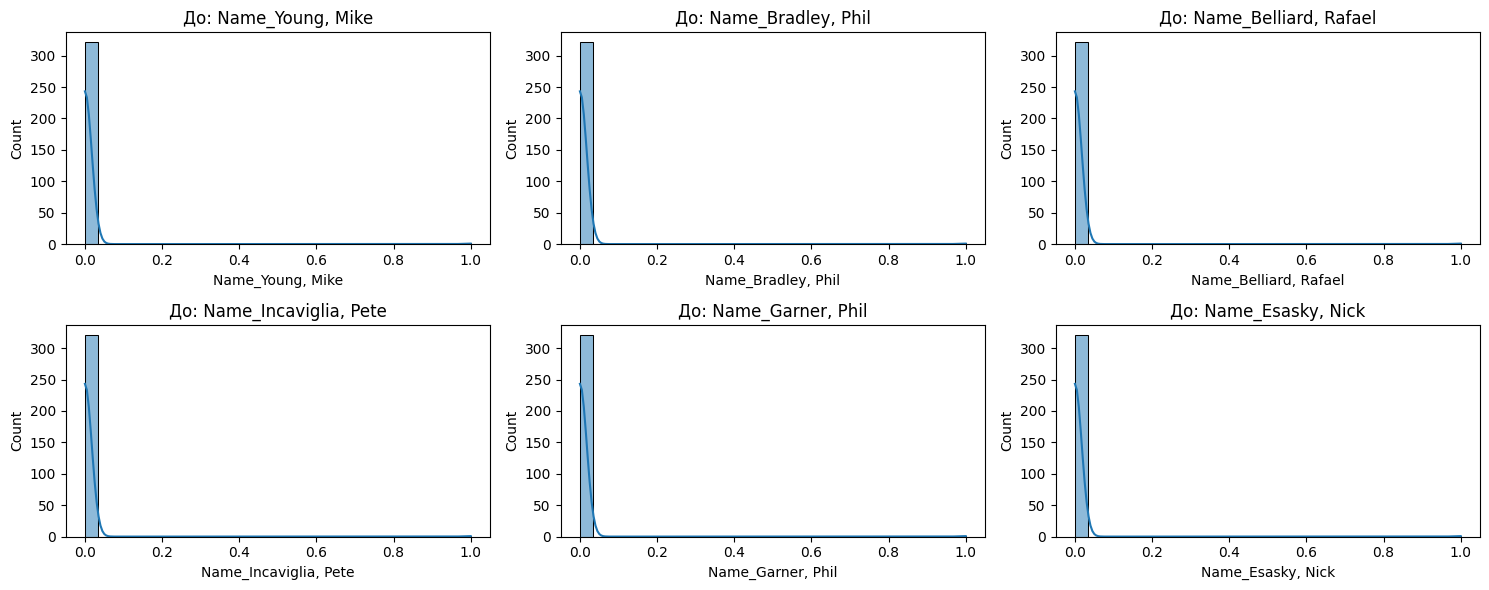

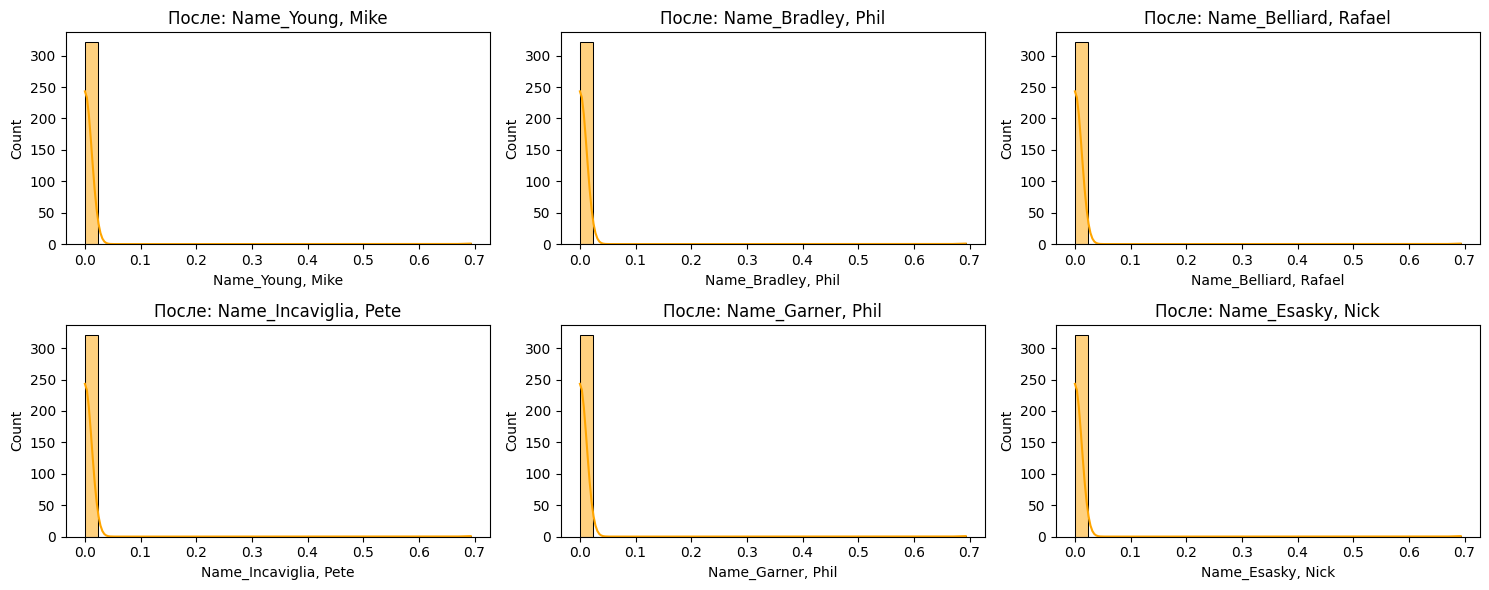

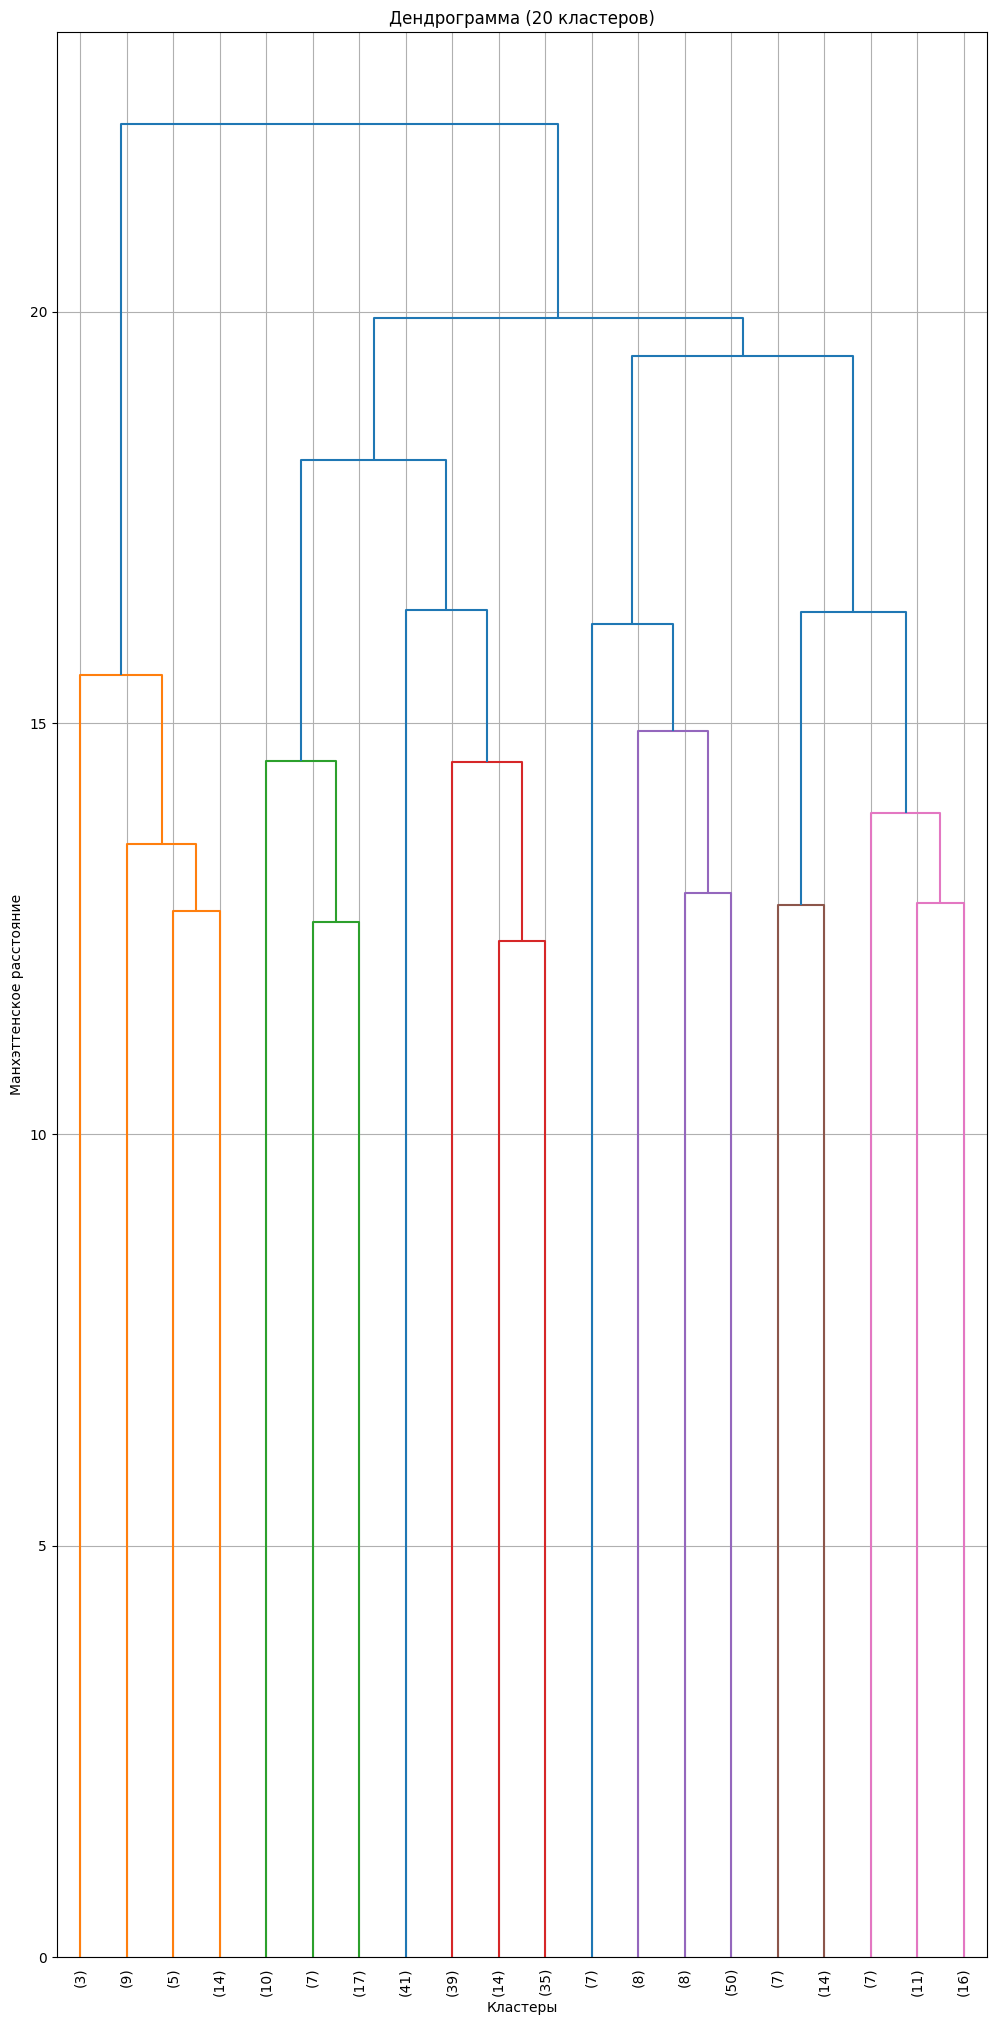

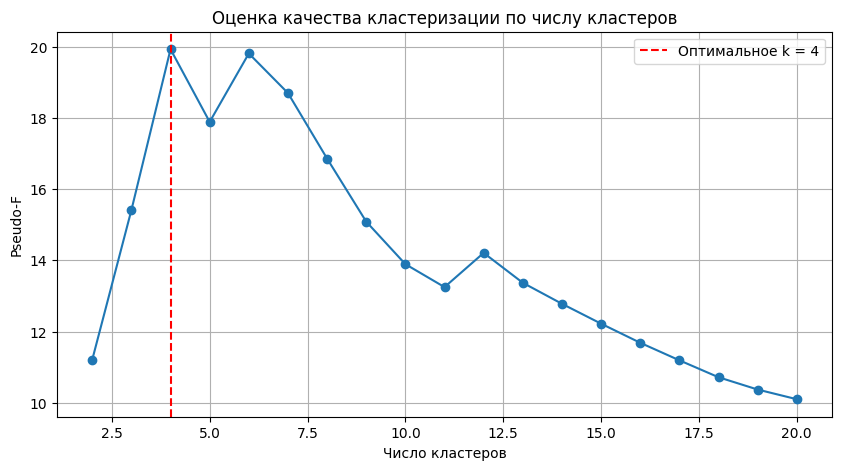

Оптимальное число кластеров: 4


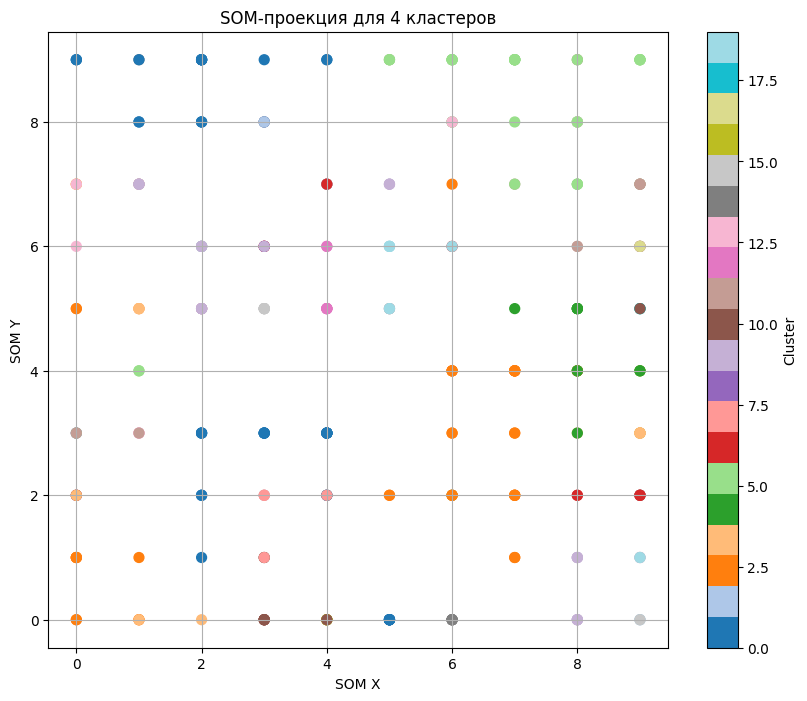

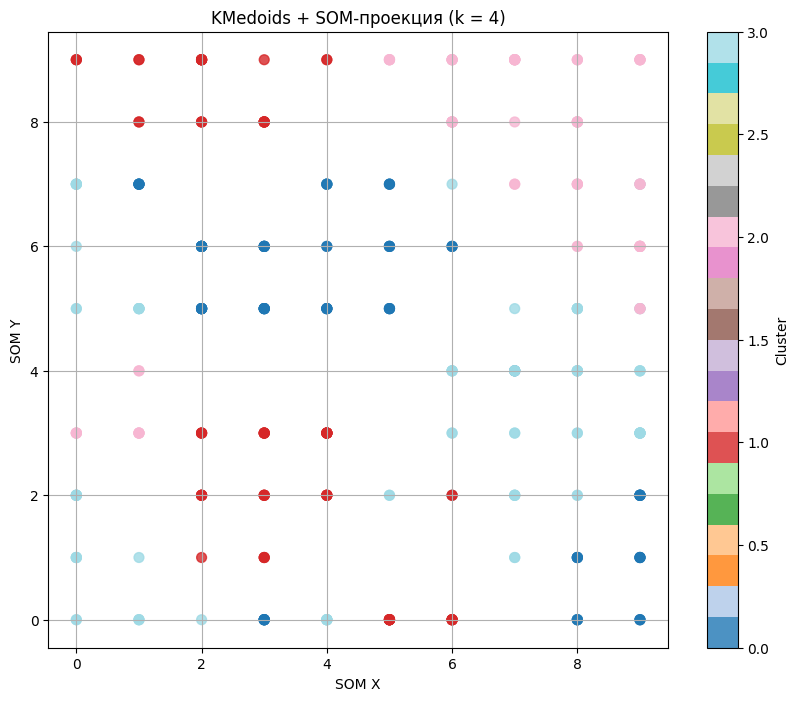


Типичные представители (медоиды):
Кластер 0: Henderson, Dave
Кластер 1: Harper, Terry
Кластер 2: Krenchicki, Wayne
Кластер 3: Hassey, Ron


In [13]:
import seaborn as sns

numeric_df = df.select_dtypes(include=[np.number])
skewness = numeric_df.skew().sort_values(ascending=False)
skewed_features = skewness[skewness > 1].index.tolist()
plt.figure(figsize=(15, 6))
for i, col in enumerate(skewed_features[:6]):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'До: {col}')
plt.tight_layout()
plt.show()

df_log = df.copy()
for col in skewed_features:
    df_log[col] = np.log1p(df_log[col])
plt.figure(figsize=(15, 6))
for i, col in enumerate(skewed_features[:6]):
    plt.subplot(2, 3, i+1)
    sns.histplot(df_log[col], kde=True, bins=30, color='orange')
    plt.title(f'После: {col}')
plt.tight_layout()
plt.show()

cluster_analysis(df_log, df_raw)


Число кластеров уменьшилось,так как логарифмирование снижает влияние выбросов и делает данные более сгруппированными 

Проекция SOM: кластеры визуально лучше разделены, особенно по оси SOM X, уменьшилось количество шумовых точек между кластерами, проекция стала лучше отражать структуру данных, так как логарифмирование снизило искажения из-за асимметрии

Кластеры на SOM стали менее перекрывающимися, результаты менее зависимы от выбросов

10. Отберите число наиболее значимых переменных из вашего варианта с помощью метода
VarClus. Запустите функцию из шага 8. Как изменилось число кластеров, проекции и лучшие
представители. Как считаете, субъективное качество кластеризации изменилось? Как и
почему?

5

Отобранные 5 наиболее значимых переменных: ['Name_Smalley, Roy', 'Name_Daulton, Darren', 'Name_Heath, Mike', 'Name_Mitchell, Kevin', 'Position_CD']


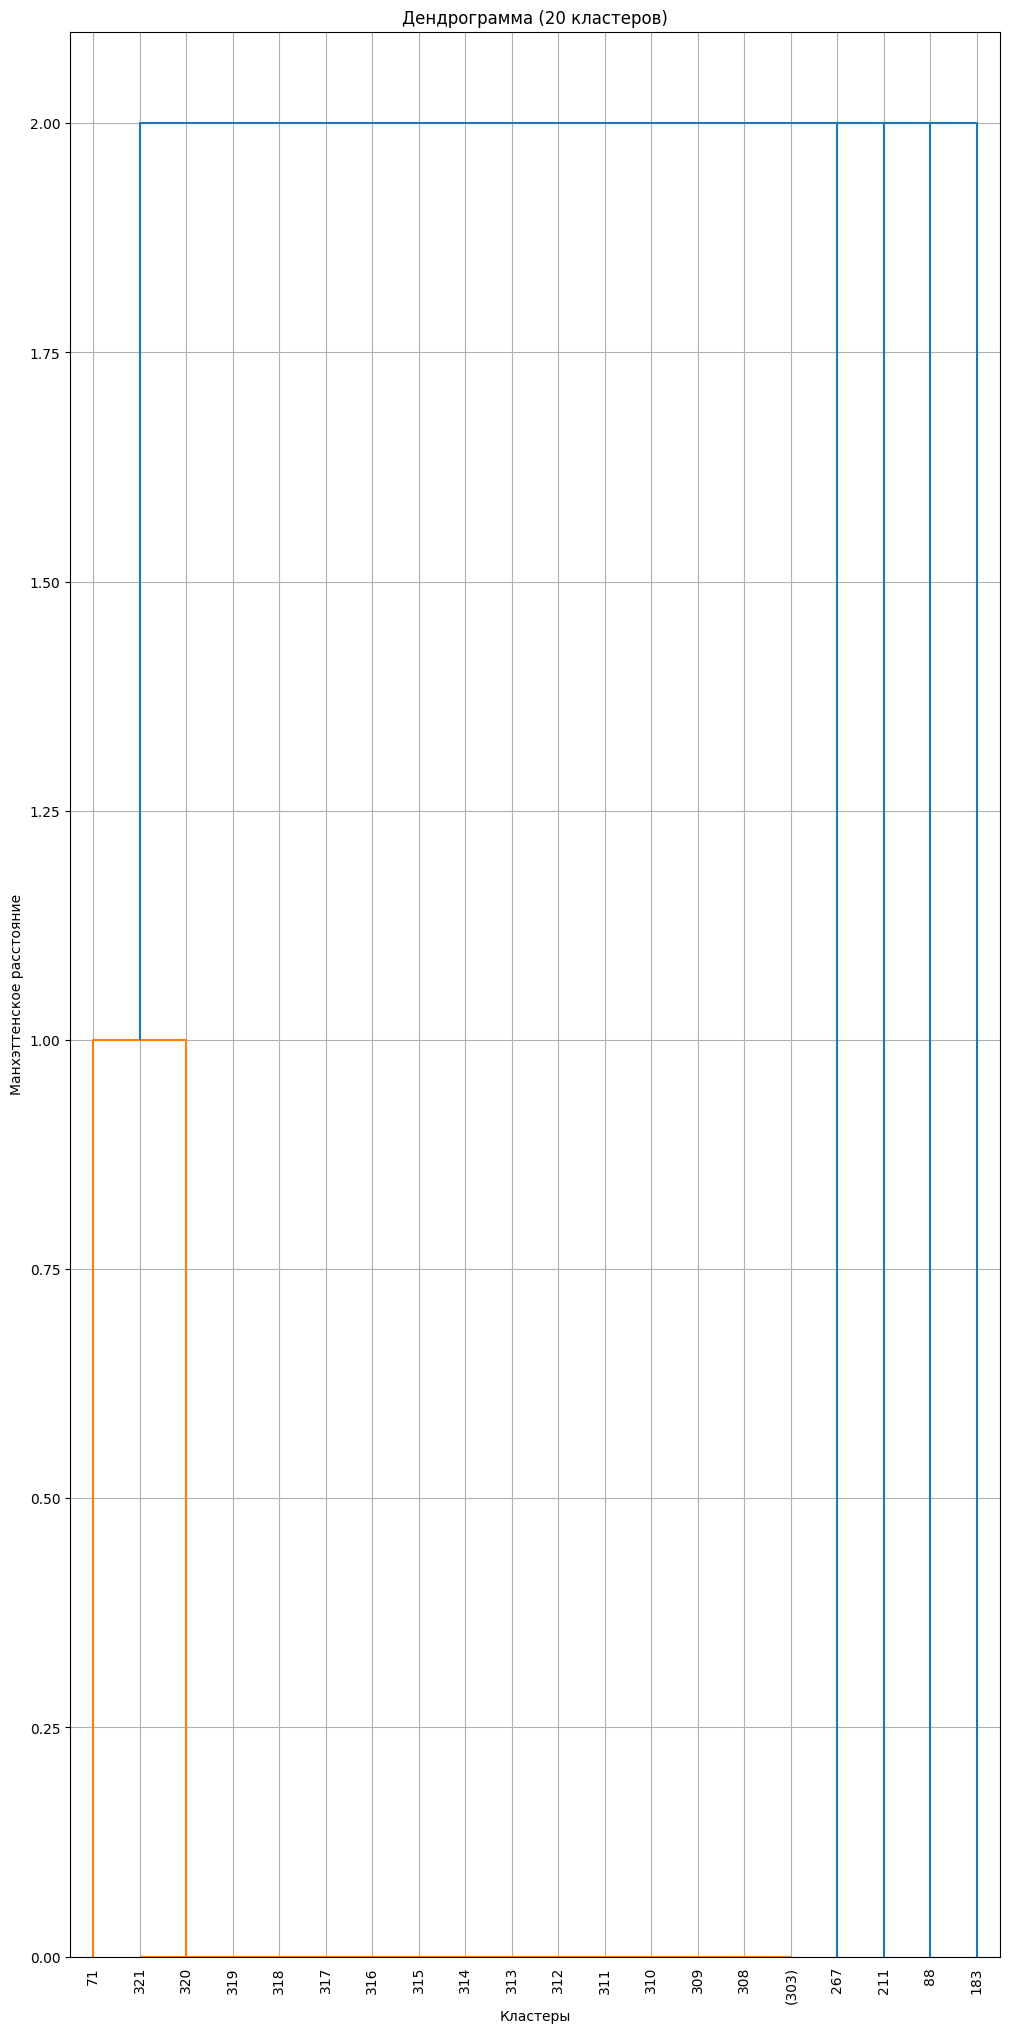

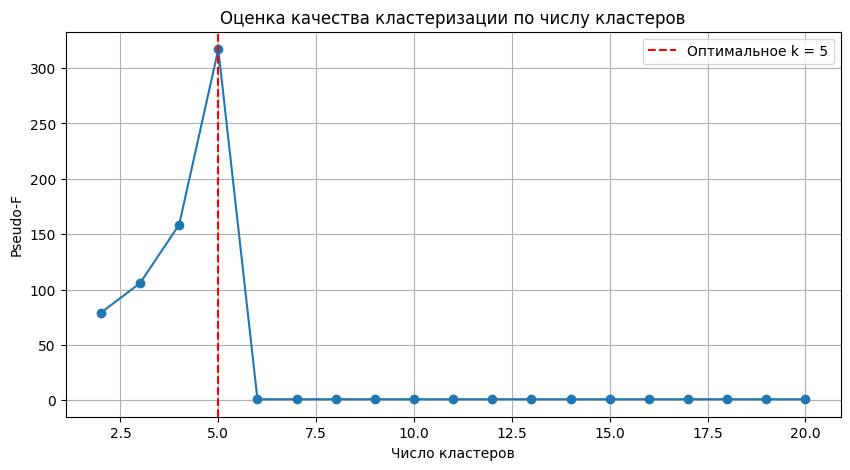

Оптимальное число кластеров: 5


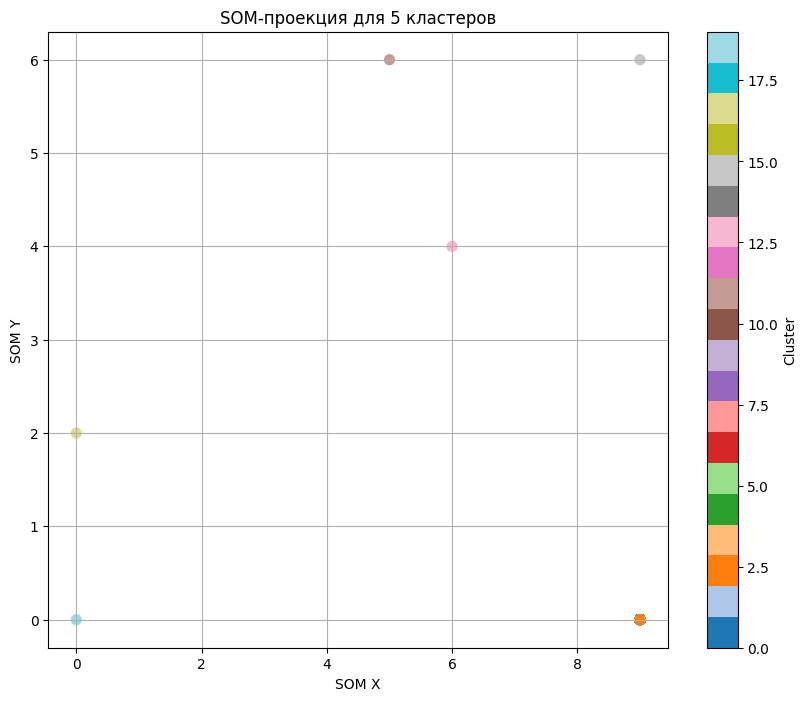

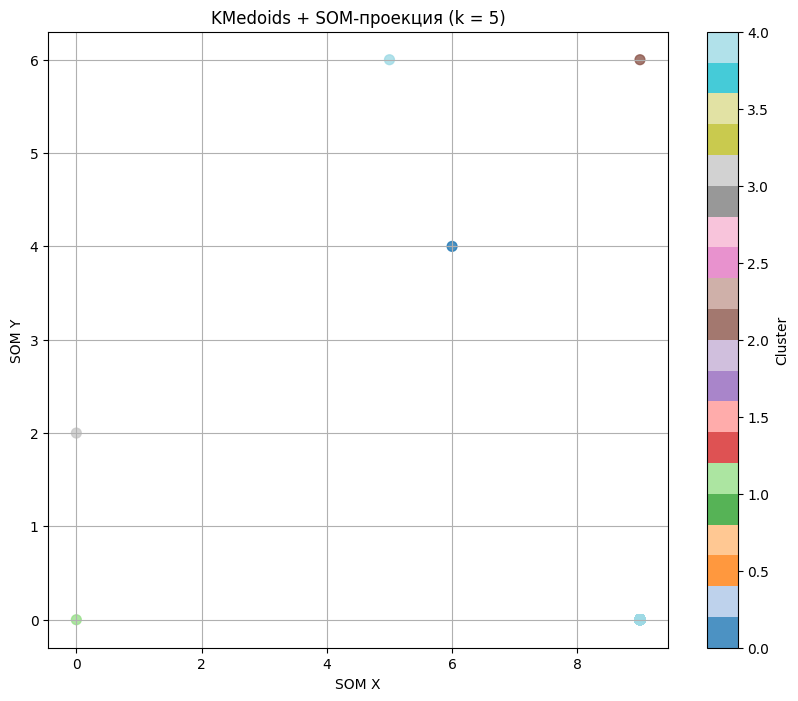


Типичные представители (медоиды):
Кластер 0: Smalley, Roy
Кластер 1: Porter, Darrell
Кластер 2: Mitchell, Kevin
Кластер 3: Heath, Mike
Кластер 4: Phillips, Tony


In [14]:
from varclushi import VarClusHi

df_varclus = df_log.copy()
vc = VarClusHi(df_varclus, maxeigval2=1, maxclus=None)
vc.varclus()

selected_features = vc.rsquare.sort_values('RS_Ratio').drop_duplicates('Cluster').Variable.tolist()[:5]
print(f"Отобранные 5 наиболее значимых переменных: {selected_features}")
df_selected = df_varclus[selected_features]
cluster_analysis(df_selected, df_raw)

Упрощение модели за счёт удаления шумовых переменных, но, возможно, произошла потеря некоторых данных. Скорее, подходит для общего анализа данных


11. 11. «Творческое задание» на поиск аномалий. Загрузите файл mnist_small.csv. Данный набор
данных содержит подмножество эталонного набора данных рукописных цифр MNIST. 5923
картинок 28x28 пикселей с изображением нуля и 76 картинок с изображением шестерки.
Задача состоит в том, чтобы с использованием методов обучения без учителя для своего
варианта построить одноклассовую модель на основе поиска аномалий, которая максимально
хорошо отфильтрует шестерки (как аномалии) от нулей (как основной выборки). Признаки
картинок описываются их координатами (в названии переменных, например «10x12») и
значением яркости точки по этим координатам. Подбирая параметры метода и преобразуя
признаки как посчитаете нужным, но не используя при этом информацию о label, постройте
модель выявления аномалий с ERR EER (Equal Error Rate) меньше 0.2.

In [1]:
import pandas as pd
import numpy as np
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve


data = pd.read_csv('~/Рабочий стол/mnist_small.csv')
X = data.drop(columns=['label'])
y = data['label'].replace({0: 0, 6: 1})

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(X)
model = OneClassSVM(nu=0.005, kernel='rbf', gamma='scale')
model.fit(x_scaled[y == 0])
anomaly_scores = -model.decision_function(x_scaled)
fpr, tpr, thresholds = roc_curve(y, anomaly_scores, pos_label=1)
fnr = 1 - tpr
eer = fpr[np.nanargmin(np.abs(fpr - fnr))]
print(f"EER: {eer:.3f}")

EER: 0.056


12. Постройте ROC кривую с ERR EER. Выведите 4 картинки с числами (28 на 28 пикселей)

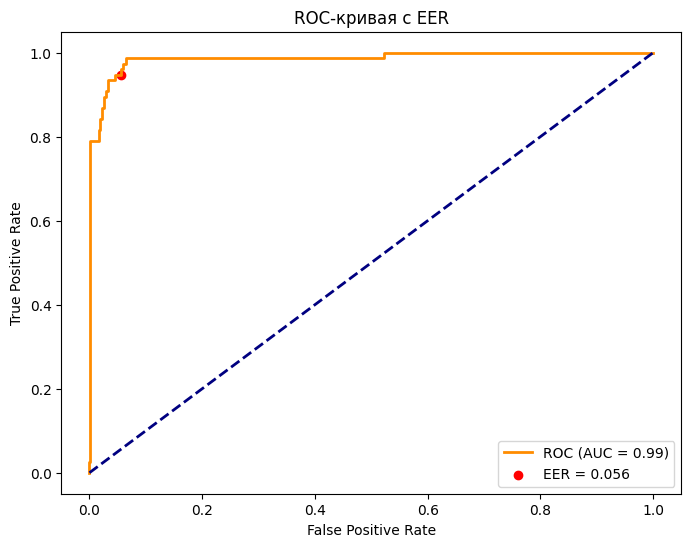

EER: 0.056


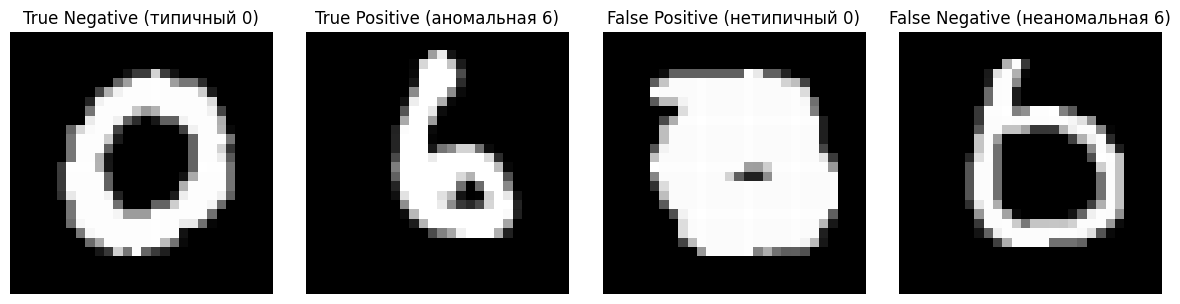

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import MinMaxScaler

X = data.drop(columns=['label'])
y = data['label'].replace({0: 0, 6: 1})

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(X)
model = OneClassSVM(nu=0.005, kernel='rbf', gamma='scale')
model.fit(x_scaled[y == 0])
anomaly_scores = -model.decision_function(x_scaled)

fpr, tpr, thresholds = roc_curve(y, anomaly_scores)
eer_threshold_idx = np.argmin(np.abs(fpr - (1 - tpr)))
eer = fpr[eer_threshold_idx]
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[eer_threshold_idx], tpr[eer_threshold_idx], color='red', label=f'EER = {eer:.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая с EER')
plt.legend()
plt.show()

print(f"EER: {eer:.3f}")
df_scores = pd.DataFrame({'label': y, 'anomaly_score': anomaly_scores})
tn = df_scores[(df_scores['label'] == 0)].nsmallest(1, 'anomaly_score')
tn_img = X.iloc[tn.index[0]].values.reshape(28, 28)
tp = df_scores[(df_scores['label'] == 1)].nlargest(1, 'anomaly_score')
tp_img = X.iloc[tp.index[0]].values.reshape(28, 28)
fp = df_scores[(df_scores['label'] == 0)].nlargest(1, 'anomaly_score')
fp_img = X.iloc[fp.index[0]].values.reshape(28, 28)
fn = df_scores[(df_scores['label'] == 1)].nsmallest(1, 'anomaly_score')
fn_img = X.iloc[fn.index[0]].values.reshape(28, 28)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
titles = ['True Negative (типичный 0)', 'True Positive (аномальная 6)',
          'False Positive (нетипичный 0)', 'False Negative (неаномальная 6)']
images = [tn_img, tp_img, fp_img, fn_img]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()